# Conditional Graph

## **Objectives**:

1. Implement `conditional logic` to route the flow of data to different nodes.
2. Use `START` and `END` nodes to manage entry and exit points explicitly.
3. Design multiple nodes to perform different operations (addition, substraction).
4. Create a `router node` to handle decision-making and control graph flow.

**Main Goal: How to use `add_conditional_edges()`**

In [50]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [51]:
class AgentState(TypedDict):
    number_1 : int
    number_2: int
    operation: str
    final_number: int

In [52]:
def addition_node(state: AgentState) -> AgentState:
    state["final_number"] = state["number_1"] + state["number_2"]
    return state

def substraction_node(state: AgentState) -> AgentState:
    state["final_number"] = state["number_1"] - state["number_2"]
    return state


---

#### `decide_next_node`

The next function is used to select the next phase of the graph, returning and **edge**. Therefore, when adding this node later on, we will need to use a lambda function

In [53]:
# This function returns an EDGE not a state, so when adding the node we will need to use a lambda function
def decide_next_node(state: AgentState) -> AgentState:
    """
    This node will select the next phase of the graph
    """

    if state["operation"] == "+":
        return "addition_operation"
    if state["operation"] == "-":
        return "substraction_operation"

In [54]:
graph = StateGraph(AgentState)

graph.add_node("add_node", addition_node)
graph.add_node("substract_node", substraction_node)




As said before, we add the router node using a lambda function that passes and returns the current state

In [55]:
# This lambda: the input state will be the output state
graph.add_node("router", lambda state: state)

# We dont use anymore set entry and set end
graph.add_edge(START, "router")


Now, for adding the **conditional edges**, we need to use the built-in function `add_conditional_edges()`.

1. First, we pass the source node.
2. Second, we add what this node needs to do, in this case, **decide the next node using `decide_next_node()`**
3. Finally, we need to pass a *path_map*, a dictionary where we define the map **Edge : Node** with the edge and the node it goes connected to.

In [56]:
# Function to add conditional edges: first part is the source node
# Second is what action needs to be done
# path_map will be a dict where we define the edges and their nodes
# therefore we make the map with the possible paths of the graph
graph.add_conditional_edges(
    "router", 
    decide_next_node,
    # Edge : Node
    path_map={
        "addition_operation": "add_node",          
        "substraction_operation": "substract_node"  
    }
)


Finally, we can add the end points using `add_edge` and passing the `END` argument to the node we want to. 

In [57]:
graph.add_edge("add_node", END)
graph.add_edge("substract_node", END)

app = graph.compile()

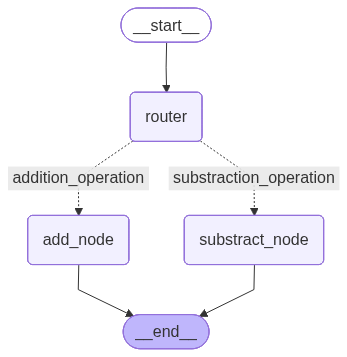

In [58]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

As we can see in the mermaid graph, the router node is considered the start node, with two conditional edges that activate two different functions depending of the state, redirecting to the subsequent node and making them the final ones.

In [59]:
initial_state_1 = AgentState(number_1= 10, operation= "-", number_2= 5)
print(app.invoke(initial_state_1))

{'number_1': 10, 'number_2': 5, 'operation': '-', 'final_number': 5}


---

# Exercise 

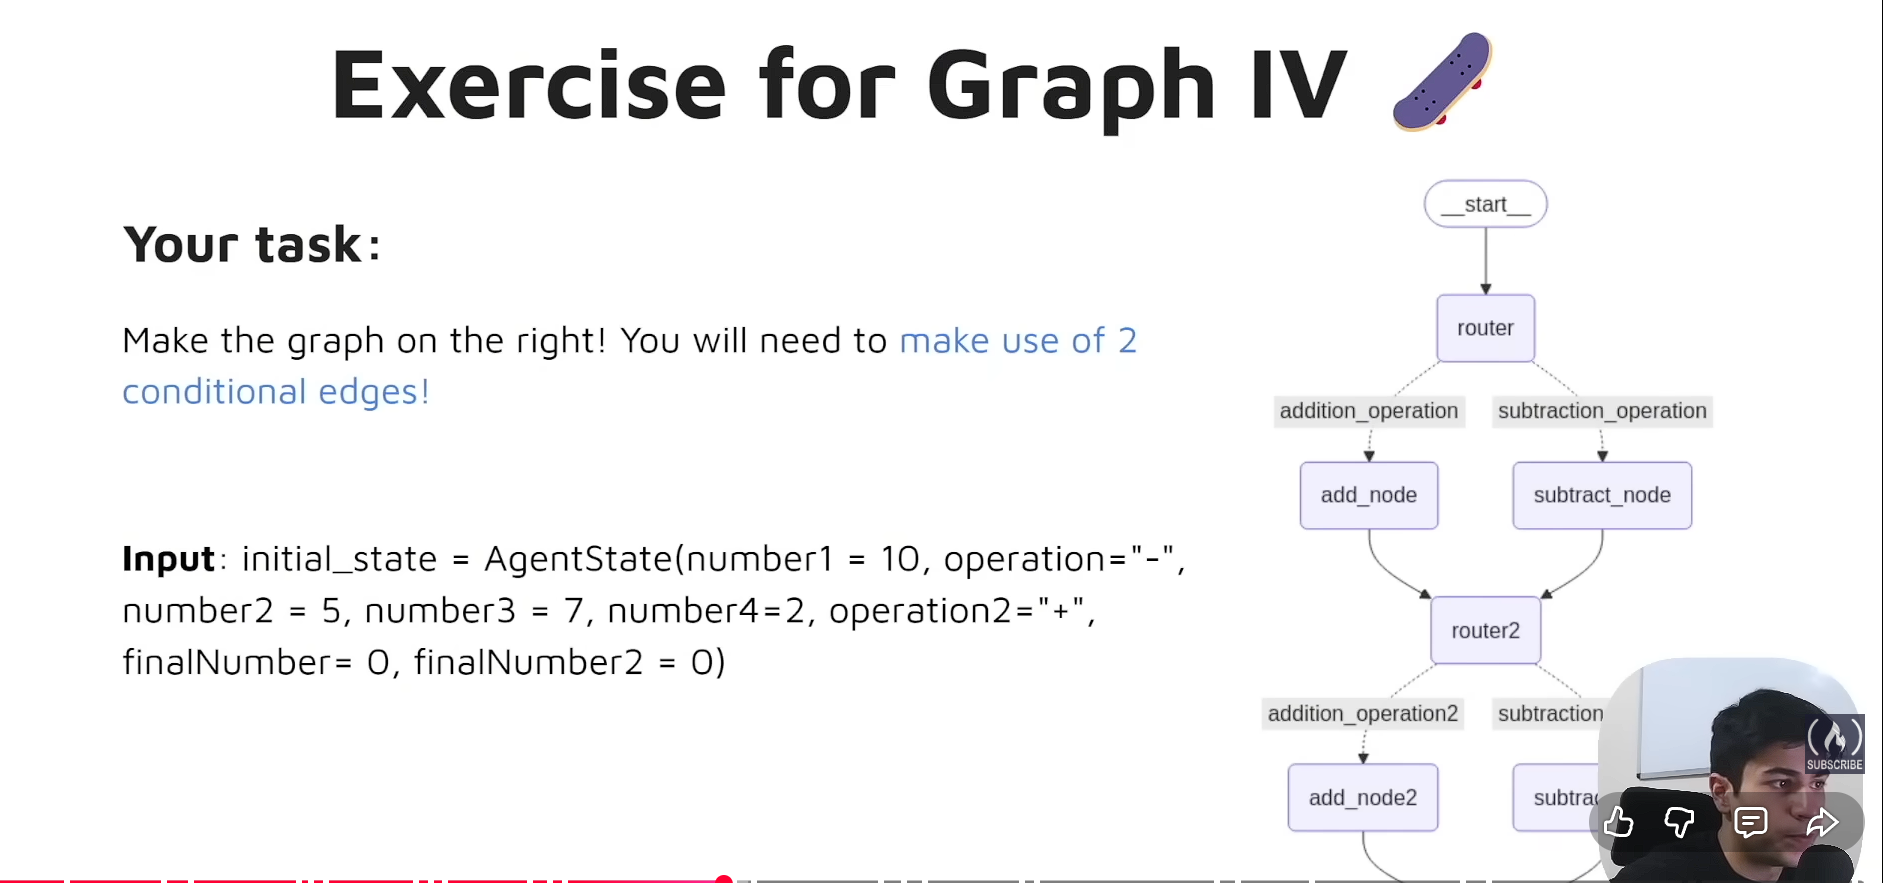

In [60]:
class AgentState_2(TypedDict):
    number_1 : int
    number_2: int
    number_3 : int
    number_4 : int
    operation_1: str
    operation_2 : str
    final_number_1: int
    final_number_2 : int

In [61]:
def addition_node(state: AgentState_2) -> AgentState_2:
    state["final_number_1"] = state["number_1"] + state["number_2"]
    return state

def substraction_node(state: AgentState_2) -> AgentState_2:
    state["final_number_1"] = state["number_1"] - state["number_2"]
    return state

def addition_node_2(state : AgentState_2) -> AgentState_2:
    state["final_number_2"] = state["final_number_1"] + state["number_3"] + state["number_4"]
    return state


def substraction_node_2(state : AgentState_2) -> AgentState_2:
    state["final_number_2"] = state["final_number_1"] - state["number_3"] - state["number_4"]
    return state


In [62]:
# This function returns an EDGE not a state, so when adding the node we will need to use a lambda function
def decide_next_node_1(state: AgentState_2) -> AgentState_2:
    """
    This node will select the next phase of the graph
    """

    if state["operation_1"] == "+":
        return "addition_operation"
    if state["operation_1"] == "-":
        return "substraction_operation"
    
def decide_next_node_2(state: AgentState_2) -> AgentState_2:
    """
    This node will select the next phase of the graph
    """

    if state["operation_2"] == "+":
        return "addition_operation_2"
    if state["operation_2"] == "-":
        return "substraction_operation_2"



In [63]:
graph = StateGraph(AgentState_2)

graph.add_node("add_node", addition_node)
graph.add_node("substract_node", substraction_node)

# This lambda: the input state will be the output state
graph.add_node("router", lambda state: state)

# We dont use anymore set entry and set end
graph.add_edge(START, "router")



# Function to add conditional edges: first part is the source node
# Second is what action needs to be done
# path_map will be a dict where we define the edges and their nodes
# therefore we make the map with the possible paths of the graph
graph.add_conditional_edges(
    "router", 
    decide_next_node_1,
    # Edge : Node
    path_map={
        "addition_operation": "add_node",          
        "substraction_operation": "substract_node"  
    }
)

graph.add_node("router_2", lambda state : state)
graph.add_node("add_node_2", addition_node_2)
graph.add_node("substract_node_2", substraction_node_2)



graph.add_edge("add_node", "router_2")
graph.add_edge("substract_node", "router_2")

graph.add_conditional_edges(
    "router_2", 
    decide_next_node_2,
    # Edge : Node
    path_map={
        "addition_operation_2": "add_node_2",          
        "substraction_operation_2": "substract_node_2"  
    }
)

graph.add_edge("add_node_2", END)
graph.add_edge("substract_node_2", END)
app = graph.compile()

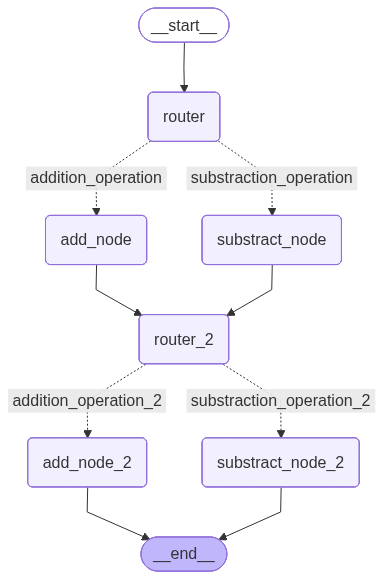

In [64]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [65]:
initial_state_2 = AgentState_2(
    number_1=10,
    number_2=5,
    number_3=7,
    number_4=2,
    operation_1="+",
    operation_2="+",
    final_number_1=0,  # valor inicial
    final_number_2=0   # valor inicial
)

print(app.invoke(initial_state_2))

{'number_1': 10, 'number_2': 5, 'number_3': 7, 'number_4': 2, 'operation_1': '+', 'operation_2': '+', 'final_number_1': 15, 'final_number_2': 24}
